In [99]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

In [100]:
df = pd.read_csv('../../data/ab-test.csv')
connect = sqlite3.connect('../../data/checking-logs.sqlite')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   uid     44 non-null     object 
 1   diff    44 non-null     float64
 2   time    44 non-null     object 
 3   group   44 non-null     object 
dtypes: float64(1), object(3)
memory usage: 1.5+ KB


In [101]:
df.head()

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test


In [102]:
req = """
SELECT
	uid,
	COUNT(uid) AS views
FROM pageviews
WHERE uid NOT LIKE 'admin%'
GROUP BY uid
"""

count_pageviews =pd.io.sql.read_sql(req, connect)
count_pageviews

,uid,views
0,user_1,28
1,user_10,89
2,user_14,143
3,user_17,47
4,user_18,3
5,user_19,16
6,user_21,10
7,user_25,179
8,user_28,149
9,user_3,317


Количество просмотров

In [103]:
req = """
SELECT
	uid,
	COUNT(uid) AS commits
FROM checker
WHERE uid NOT LIKE 'admin%' and labname != 'project1' and status='ready' 
GROUP BY uid
"""

count_commits =pd.io.sql.read_sql(req, connect)
count_commits


,uid,commits
0,user_0,2
1,user_1,35
2,user_10,13
3,user_11,4
4,user_12,45
5,user_13,28
6,user_14,33
7,user_15,14
8,user_16,23
9,user_17,29


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   uid     44 non-null     object 
 1   diff    44 non-null     float64
 2   time    44 non-null     object 
 3   group   44 non-null     object 
dtypes: float64(1), object(3)
memory usage: 1.5+ KB


In [105]:

merged = df.merge(count_pageviews, on='uid', how='left').merge(count_commits, on='uid', how='left').fillna(0)
merged.head(10)

,uid,diff,time,group,views,commits
0,user_1,-103.333333,after,test,28.0,35
1,user_1,-6.000000,before,test,28.0,35
2,user_18,-10.000000,after,test,3.0,4
3,user_18,-3.500000,before,test,3.0,4
4,user_19,-82.333333,after,test,16.0,62
5,user_19,-148.000000,before,test,16.0,62
6,user_21,-78.500000,after,test,10.0,35
7,user_21,-112.500000,before,test,10.0,35
8,user_25,-127.500000,after,test,179.0,43
9,user_25,-69.333333,before,test,179.0,43


In [106]:
merged_before = merged[merged['time']=='before'].drop('time', axis = 1)
merged_after = merged[merged['time']=='after'].drop('time', axis = 1)

In [107]:
merged_after.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22 entries, 0 to 42
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   uid      22 non-null     object 
 1   diff     22 non-null     float64
 2   group    22 non-null     object 
 3   views    22 non-null     float64
 4   commits  22 non-null     int64  
dtypes: float64(2), int64(1), object(2)
memory usage: 1.0+ KB


In [108]:
merged_after_copy = merged_after.copy()
merged_after_copy = merged_after_copy.drop(columns = ['group', 'uid'], axis =1)

merged_before_copy = merged_before.copy()
merged_before_copy = merged_before_copy.drop(columns = ['group', 'uid'], axis =1)

merged_copy = merged.copy()
merged_copy = merged_copy.drop(columns = ['group', 'uid', 'time'], axis =1)

создаем матрицу графиков для данных полсе A/B теста

array([[<Axes: xlabel='diff', ylabel='diff'>,
        <Axes: xlabel='views', ylabel='diff'>,
        <Axes: xlabel='commits', ylabel='diff'>],
       [<Axes: xlabel='diff', ylabel='views'>,
        <Axes: xlabel='views', ylabel='views'>,
        <Axes: xlabel='commits', ylabel='views'>],
       [<Axes: xlabel='diff', ylabel='commits'>,
        <Axes: xlabel='views', ylabel='commits'>,
        <Axes: xlabel='commits', ylabel='commits'>]], dtype=object)

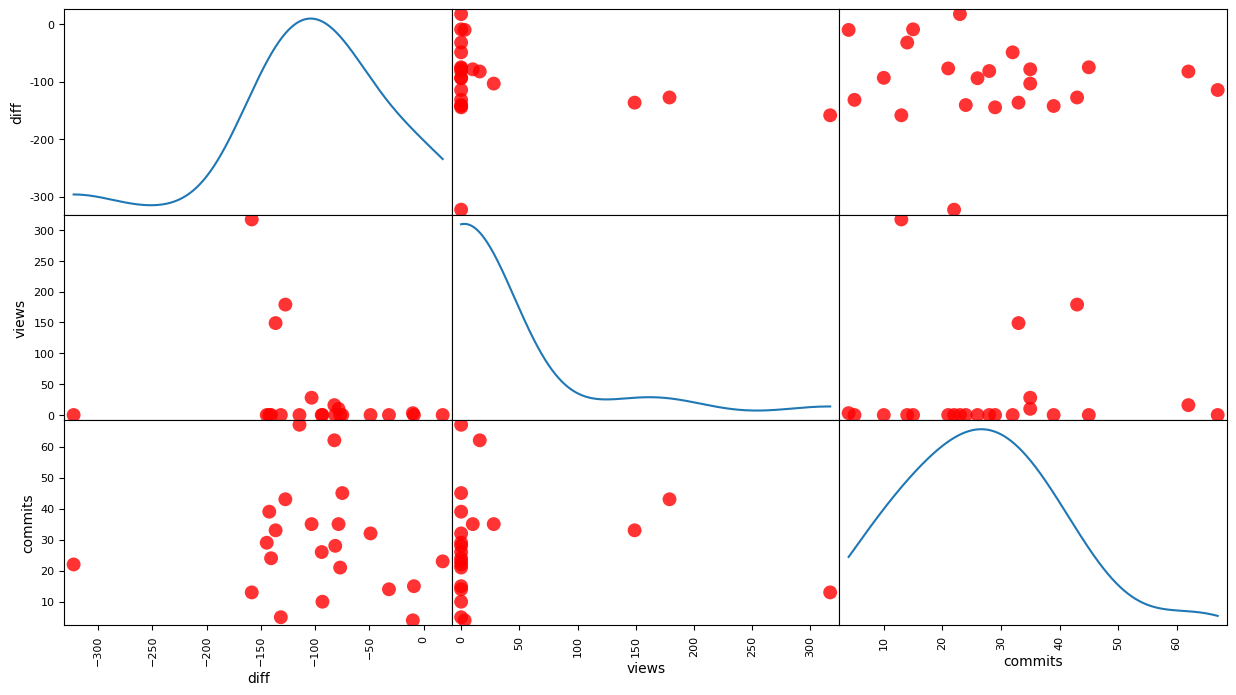

In [109]:
scatter_matrix(
    merged_after_copy, 
    alpha=0.8,                 
    figsize=(15, 8),          
    diagonal='kde',             
    color='red',                
    s=100,                      
    marker='o',                 
    grid=True                   
)

"Можем ли мы сказать, что если у пользователя мало просмотров страниц, то, скорее всего, у него мало коммитов?" Ответ - да или нет.\

"Можем ли мы сказать, что если у пользователя небольшое количество просмотров страниц, то, скорее всего, у него небольшая средняя разница между первым коммитом и крайним сроком выполнения лабораторной работы?" Ответ - да или нет.\

"Можем ли мы сказать, что есть много пользователей с низким числом коммитов и несколько с высоким числом коммитов?" Ответ - да или нет.\

"Можем ли мы сказать, что есть много пользователей с небольшой средней разницей и несколько пользователей с большой средней разницей?" Ответ - да или нет.


Ответ: 
1) Нет
2) Нет
3) Да
4) нет

In [110]:
connect.close()